Обработка изображения: document_with_tables.jpg
Размер: 1400x1000
--------------------------------------------------
1. Предобработка...
2. Детекция MSER...
   Найдено регионов: 163
3. Удаление дубликатов...
   Уникальных регионов: 8
4. Кластеризация блоков...
   Найдено кластеров: 0
5. Уточнение границ таблиц...
6. Финальная проверка...
   Итоговое количество таблиц: 0
   Результат сохранен: result_with_tables.jpg


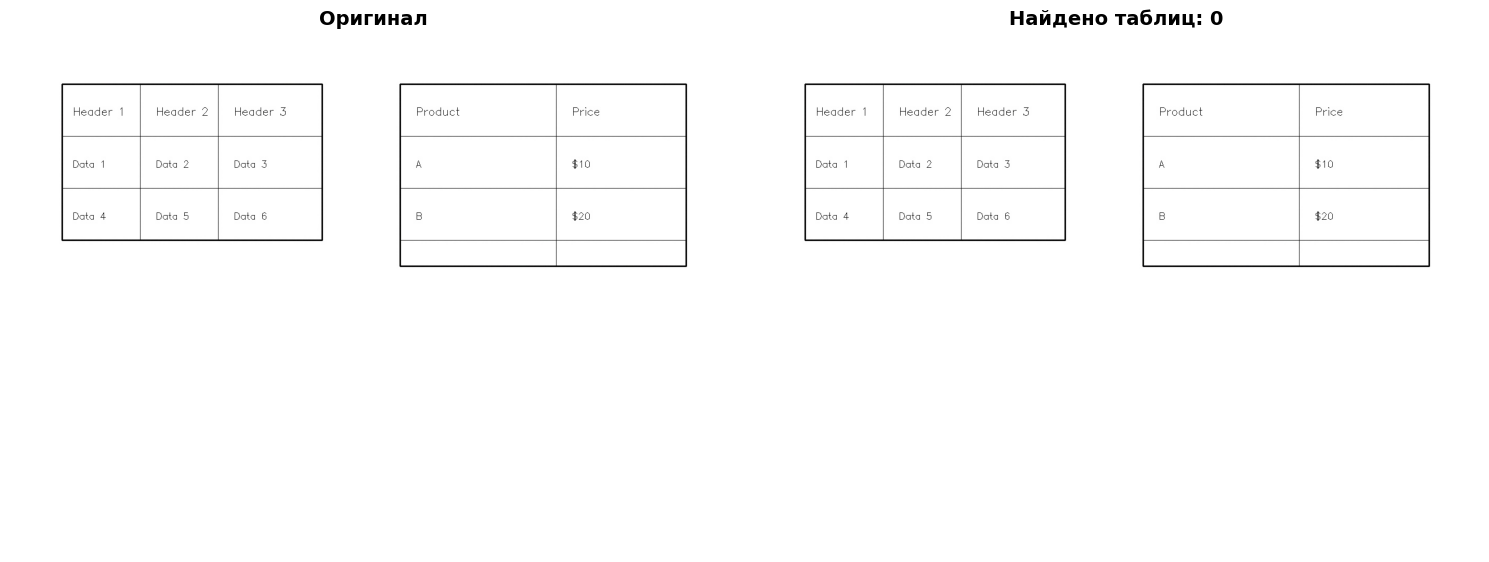


РЕЗУЛЬТАТЫ ДЕТЕКЦИИ:


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from collections import defaultdict
import os

class TableDetectorMSER:
    """
    Детектор таблиц в документах с использованием MSER
    + постобработка для группировки блоков в таблицы
    """
    
    def __init__(self, 
                 min_area=200,
                 max_area=50000,
                 max_variation=0.5,
                 min_delta=3,
                 max_delta=10,
                 eps_cluster=30,
                 min_samples=2):
        """
        Args:
            min_area: Минимальная площадь региона MSER
            max_area: Максимальная площадь региона MSER
            max_variation: Максимальная вариативность региона
            min_delta: Минимальная разница между порогами
            max_delta: Максимальная разница между порогами
            eps_cluster: Радиус кластеризации для группировки блоков
            min_samples: Минимальное количество точек для кластера
        """
        self.min_area = min_area
        self.max_area = max_area
        self.max_variation = max_variation
        self.min_delta = min_delta
        self.max_delta = max_delta
        self.eps_cluster = eps_cluster
        self.min_samples = min_samples
        
    def preprocess_image(self, image):
        """
        Предобработка изображения для улучшения детекции
        """
        # Конвертация в оттенки серого
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
            
        # Применение CLAHE для улучшения контраста
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        
        # Удаление шума
        denoised = cv2.fastNlMeansDenoising(enhanced, h=10)
        
        return denoised
    
    def detect_regions(self, gray_image):
        """
        Детекция регионов с помощью MSER с адаптивными параметрами
        """
        # Адаптивный подбор параметров на основе изображения
        height, width = gray_image.shape
        image_area = height * width
        
        # Настройка параметров в зависимости от размера изображения
        min_area = max(self.min_area, image_area * 0.0005)  # 0.05% от площади
        max_area = min(self.max_area, image_area * 0.3)     # 30% от площади
        
        # Создание MSER детектора (исправленный API)
        mser = cv2.MSER_create()
        mser.setMinArea(int(min_area))
        mser.setMaxArea(int(max_area))
        mser.setMaxVariation(self.max_variation)
        
        # Детекция регионов
        regions, bboxes = mser.detectRegions(gray_image)
        
        return regions, bboxes
    
    def filter_bboxes(self, bboxes, image_shape):
        """
        Фильтрация bounding boxes по геометрическим критериям
        """
        height, width = image_shape[:2]
        filtered_bboxes = []
        
        for (x, y, w, h) in bboxes:
            # Пропускаем слишком маленькие
            if w * h < self.min_area * 2:
                continue
                
            # Пропускаем слишком большие
            if w * h > self.max_area * 2:
                continue
                
            # Пропускаем вытянутые (не табличные)
            aspect_ratio = max(w, h) / min(w, h) if min(w, h) > 0 else 0
            if aspect_ratio > 5:  # Слишком вытянутые
                continue
                
            # Пропускаем слишком близкие к краям
            if x < 10 or y < 10 or x + w > width - 10 or y + h > height - 10:
                continue
                
            # Проверка на заполненность (есть ли внутри текст)
            if w * h < 500:  # Слишком маленькие блоки
                continue
                
            filtered_bboxes.append((x, y, w, h))
            
        return filtered_bboxes
    
    def cluster_bboxes(self, bboxes):
        """
        Группировка bounding boxes в кластеры (таблицы)
        Использует DBSCAN для кластеризации по центроидам
        """
        if not bboxes:
            return []
            
        # Извлечение центроидов
        centroids = []
        for (x, y, w, h) in bboxes:
            cx = x + w // 2
            cy = y + h // 2
            centroids.append([cx, cy])
            
        # Кластеризация
        clustering = DBSCAN(eps=self.eps_cluster, 
                           min_samples=self.min_samples).fit(centroids)
        
        # Группировка по кластерам
        clusters = defaultdict(list)
        for idx, label in enumerate(clustering.labels_):
            if label != -1:  # Игнорируем шум
                clusters[label].append(bboxes[idx])
                
        # Объединение блоков в каждом кластере
        grouped_bboxes = []
        for cluster_bboxes in clusters.values():
            if len(cluster_bboxes) >= 2:  # Минимум 2 блока для таблицы
                # Находим общий bounding box для кластера
                x_min = min(b[0] for b in cluster_bboxes)
                y_min = min(b[1] for b in cluster_bboxes)
                x_max = max(b[0] + b[2] for b in cluster_bboxes)
                y_max = max(b[1] + b[3] for b in cluster_bboxes)
                
                grouped_bboxes.append((x_min, y_min, x_max - x_min, y_max - y_min))
                
        return grouped_bboxes
    
    def refine_tables(self, image, grouped_bboxes):
        """
        Уточнение границ таблиц через анализ проекций
        """
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, 
                                  cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        
        refined_bboxes = []
        for (x, y, w, h) in grouped_bboxes:
            # Вырезаем область
            roi = binary[y:y+h, x:x+w]
            
            if roi.size == 0:
                continue
                
            # Вертикальная проекция (для уточнения левой и правой границы)
            vertical_proj = np.sum(roi, axis=0)
            threshold = np.max(vertical_proj) * 0.05
            
            # Находим границы по проекции
            non_zero = np.where(vertical_proj > threshold)[0]
            if len(non_zero) > 0:
                left = non_zero[0]
                right = non_zero[-1]
                
                # Горизонтальная проекция (для уточнения верхней и нижней границы)
                horizontal_proj = np.sum(roi, axis=1)
                threshold_h = np.max(horizontal_proj) * 0.05
                non_zero_h = np.where(horizontal_proj > threshold_h)[0]
                
                if len(non_zero_h) > 0:
                    top = non_zero_h[0]
                    bottom = non_zero_h[-1]
                    
                    refined_bboxes.append((x + left, y + top, 
                                          right - left + 1, bottom - top + 1))
                else:
                    refined_bboxes.append((x, y, w, h))
            else:
                refined_bboxes.append((x, y, w, h))
                
        return refined_bboxes
    
    def detect_tables(self, image_path, visualize=True, save_path=None):
        """
        Основной метод детекции таблиц
        """
        # Загрузка изображения
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Не удалось загрузить изображение: {image_path}")
            
        original = image.copy()
        height, width = image.shape[:2]
        
        print(f"Обработка изображения: {image_path}")
        print(f"Размер: {width}x{height}")
        print("-" * 50)
        
        # 1. Предобработка
        print("1. Предобработка...")
        gray = self.preprocess_image(image)
        
        # 2. Детекция MSER с разными параметрами
        print("2. Детекция MSER...")
        all_bboxes = []
        
        # Создаем базовый MSER детектор
        mser = cv2.MSER_create()
        
        # Пробуем разные параметры delta
        for delta in range(self.min_delta, self.max_delta + 1, 2):
            # Устанавливаем параметры через set методы
            mser.setDelta(delta)
            mser.setMinArea(int(self.min_area))
            mser.setMaxArea(int(self.max_area))
            mser.setMaxVariation(self.max_variation)
            
            # Детекция
            _, bboxes = mser.detectRegions(gray)
            
            # Фильтрация
            filtered = self.filter_bboxes(bboxes, image.shape)
            all_bboxes.extend(filtered)
            
        print(f"   Найдено регионов: {len(all_bboxes)}")
        
        # 3. Удаление дубликатов (пересекающиеся боксы)
        print("3. Удаление дубликатов...")
        unique_bboxes = self.remove_overlapping(all_bboxes)
        print(f"   Уникальных регионов: {len(unique_bboxes)}")
        
        # 4. Кластеризация
        print("4. Кластеризация блоков...")
        grouped_bboxes = self.cluster_bboxes(unique_bboxes)
        print(f"   Найдено кластеров: {len(grouped_bboxes)}")
        
        # 5. Уточнение границ
        print("5. Уточнение границ таблиц...")
        refined_bboxes = self.refine_tables(image, grouped_bboxes)
        
        # 6. Дополнительная проверка на таблицы
        print("6. Финальная проверка...")
        final_tables = self.validate_tables(image, refined_bboxes)
        print(f"   Итоговое количество таблиц: {len(final_tables)}")
        
        # 7. Визуализация
        if visualize:
            result = self.visualize_tables(original, final_tables)
            
            if save_path:
                cv2.imwrite(save_path, result)
                print(f"   Результат сохранен: {save_path}")
                
            self.show_result(original, result, final_tables)
            
        return final_tables
    
    def remove_overlapping(self, bboxes, iou_threshold=0.3):
        """
        Удаление пересекающихся боксов с помощью NMS
        """
        if not bboxes:
            return []
            
        # Конвертация в формат для NMS
        boxes = []
        scores = []
        for (x, y, w, h) in bboxes:
            boxes.append([x, y, x+w, y+h])
            scores.append(w * h)
        
        boxes = np.array(boxes, dtype=np.float32)
        scores = np.array(scores, dtype=np.float32)
        
        # Применение NMS
        indices = cv2.dnn.NMSBoxes(
            boxes.tolist(), 
            scores.tolist(), 
            score_threshold=0.5,
            nms_threshold=iou_threshold
        )
        
        if len(indices) > 0:
            indices = indices.flatten()
            return [bboxes[i] for i in indices]
        else:
            return []
    
    def validate_tables(self, image, bboxes):
        """
        Валидация найденных таблиц по дополнительным критериям
        """
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, 
                                  cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        
        valid_tables = []
        
        for (x, y, w, h) in bboxes:
            # Проверка на слишком маленькие области
            if w * h < 1000:
                continue
                
            # Проверка на соотношение сторон (таблица обычно не квадратная)
            aspect = max(w, h) / min(w, h) if min(w, h) > 0 else 0
            if aspect < 1.2:  # Почти квадратные - скорее всего не таблица
                continue
                
            # Проверка на плотность текста внутри области
            roi = binary[y:y+h, x:x+w]
            if roi.size == 0:
                continue
                
            # Доля черных пикселей (текст)
            text_density = np.sum(roi) / 255 / roi.size
            
            # В таблице должно быть достаточно текста
            if text_density < 0.01 or text_density > 0.6:
                continue
                
            # Проверка на наличие линий сетки
            lines = self.detect_grid_lines(roi)
            if lines < 2:  # Минимум 2 линии для таблицы
                continue
                
            valid_tables.append((x, y, w, h))
            
        return valid_tables
    
    def detect_grid_lines(self, roi):
        """
        Детекция линий сетки внутри области
        """
        # Детекция горизонтальных линий
        horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 1))
        horizontal_lines = cv2.morphologyEx(roi, cv2.MORPH_OPEN, horizontal_kernel)
        
        # Детекция вертикальных линий
        vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 20))
        vertical_lines = cv2.morphologyEx(roi, cv2.MORPH_OPEN, vertical_kernel)
        
        # Подсчет линий через анализ проекций
        h_proj = np.sum(horizontal_lines, axis=1)
        v_proj = np.sum(vertical_lines, axis=0)
        
        h_lines = np.sum(h_proj > np.max(h_proj) * 0.1)
        v_lines = np.sum(v_proj > np.max(v_proj) * 0.1)
        
        return h_lines + v_lines
    
    def visualize_tables(self, image, bboxes):
        """
        Визуализация найденных таблиц
        """
        result = image.copy()
        
        # Случайные цвета для каждой таблицы
        colors = [
            (0, 255, 0),    # Зеленый
            (255, 0, 0),    # Синий
            (0, 0, 255),    # Красный
            (255, 255, 0),  # Голубой
            (255, 0, 255),  # Пурпурный
            (0, 255, 255)   # Желтый
        ]
        
        for idx, (x, y, w, h) in enumerate(bboxes):
            color = colors[idx % len(colors)]
            
            # Рисуем прямоугольник
            cv2.rectangle(result, (x, y), (x+w, y+h), color, 3)
            
            # Добавляем номер таблицы
            label = f"Table {idx + 1}"
            cv2.putText(result, label, (x, y-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            # Добавляем размеры
            size_label = f"{w}x{h}"
            cv2.putText(result, size_label, (x, y+h+20), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
            
        return result
    
    def show_result(self, original, result, bboxes):
        """
        Отображение результата с помощью matplotlib
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))
        
        # Оригинал
        ax1.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        ax1.set_title('Оригинал', fontsize=14, fontweight='bold')
        ax1.axis('off')
        
        # Результат
        ax2.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        ax2.set_title(f'Найдено таблиц: {len(bboxes)}', 
                     fontsize=14, fontweight='bold')
        ax2.axis('off')
        
        plt.tight_layout()
        plt.show()


# ==================== ИСПОЛЬЗОВАНИЕ ====================

def demo_table_detection():
    """
    Демонстрация работы детектора таблиц
    """
    # Создание детектора
    detector = TableDetectorMSER(
        min_area=200,        # Минимальная площадь региона
        max_area=50000,      # Максимальная площадь региона
        max_variation=0.5,   # Вариативность
        min_delta=3,         # Минимальная дельта
        max_delta=10,        # Максимальная дельта
        eps_cluster=40,      # Радиус кластеризации
        min_samples=2        # Минимальное количество точек
    )
    
    # Путь к изображению
    image_path = "document_with_tables.jpg"
    
    # Если файл не существует, создаем тестовое изображение
    if not os.path.exists(image_path):
        print("Создание тестового изображения...")
        create_test_image(image_path)
    
    # Детекция таблиц
    tables = detector.detect_tables(
        image_path=image_path,
        visualize=True,
        save_path="result_with_tables.jpg"
    )
    
    # Вывод информации о найденных таблицах
    print("\n" + "="*50)
    print("РЕЗУЛЬТАТЫ ДЕТЕКЦИИ:")
    for i, (x, y, w, h) in enumerate(tables):
        print(f"  Таблица {i+1}:")
        print(f"    Позиция: x={x}, y={y}")
        print(f"    Размер: {w}x{h}")
        print(f"    Площадь: {w*h} px²")
    print("="*50)


def create_test_image(path):
    """
    Создание тестового изображения с таблицами
    """
    # Создаем белый фон
    img = np.ones((1000, 1400, 3), dtype=np.uint8) * 255
    
    # Рисуем первую таблицу
    cv2.rectangle(img, (100, 100), (600, 400), (0, 0, 0), 2)
    cv2.line(img, (100, 200), (600, 200), (0, 0, 0), 1)
    cv2.line(img, (100, 300), (600, 300), (0, 0, 0), 1)
    cv2.line(img, (250, 100), (250, 400), (0, 0, 0), 1)
    cv2.line(img, (400, 100), (400, 400), (0, 0, 0), 1)
    
    # Добавляем текст в первую таблицу
    cv2.putText(img, "Header 1", (120, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 1)
    cv2.putText(img, "Header 2", (280, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 1)
    cv2.putText(img, "Header 3", (430, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 1)
    cv2.putText(img, "Data 1", (120, 260), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    cv2.putText(img, "Data 2", (280, 260), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    cv2.putText(img, "Data 3", (430, 260), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    cv2.putText(img, "Data 4", (120, 360), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    cv2.putText(img, "Data 5", (280, 360), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    cv2.putText(img, "Data 6", (430, 360), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    
    # Рисуем вторую таблицу
    cv2.rectangle(img, (750, 100), (1300, 450), (0, 0, 0), 2)
    cv2.line(img, (750, 200), (1300, 200), (0, 0, 0), 1)
    cv2.line(img, (750, 300), (1300, 300), (0, 0, 0), 1)
    cv2.line(img, (750, 400), (1300, 400), (0, 0, 0), 1)
    cv2.line(img, (1050, 100), (1050, 450), (0, 0, 0), 1)
    
    # Добавляем текст во вторую таблицу
    cv2.putText(img, "Product", (780, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 1)
    cv2.putText(img, "Price", (1080, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 1)
    cv2.putText(img, "A", (780, 260), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    cv2.putText(img, "$10", (1080, 260), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    cv2.putText(img, "B", (780, 360), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    cv2.putText(img, "$20", (1080, 360), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    
    # Добавляем немного шума
    noise = np.random.randint(0, 10, img.shape, dtype=np.uint8)
    img = cv2.add(img, noise)
    
    # Сохранение
    cv2.imwrite(path, img)
    print(f"Тестовое изображение создано: {path}")


if __name__ == "__main__":
    demo_table_detection()